In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import root_mean_squared_error as rmse
import time
import tkinter as tk
from tkinter import messagebox
import math
import matplotlib as mpl
from scipy.spatial import ConvexHull
import os
# our functions
import predict_Beta_I
import choice_start_day
import plot_hyb

import warnings
warnings.filterwarnings(action='ignore')

# to account for updates when files change
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<Axes: >

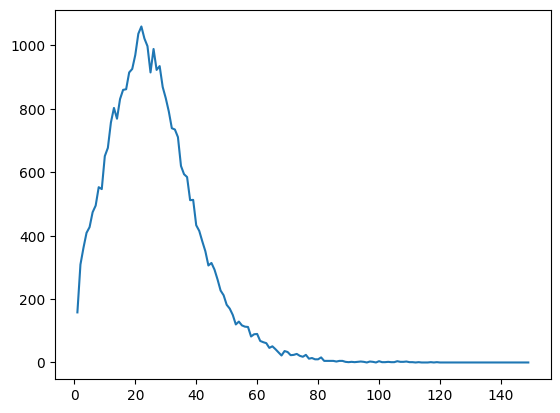

In [2]:
seed_dirs="../new_ba_100000/"
sw = pd.read_csv('test_files.csv').values
seed_df = pd.read_csv(seed_dirs+sw[::10][1801][0])
chosen_col='incidence'
temp = seed_df[['E','S']].shift([0,1])
# Inc_t = (E_t-1 - E_t) - (S_t - S_t-1)
seed_df['incidence'] = (temp['E_1'] - temp['E_0']) - \
                                (temp['S_0'] - temp['S_1'])
seed_df.incidence.plot()

In [3]:
switch = 10
sigma=0.3
gamma=0.2
y = seed_df.iloc[switch,:4]
betas = seed_df.Beta.iloc[switch:].values
betas = seed_df.Beta.iloc[switch:
                         ].rolling(4).mean().fillna(method='bfill').values*.98
s,e,i,r = predict_Beta_I.predict_I('seir',
                                   y, 
                                   np.arange(seed_df.shape[0]-switch)+switch, 
                                   betas,
                                   sigma, gamma, 
                                   'd', True)

from_last = seed_df['incidence'].iloc[switch]
predicted_Inc = np.append(from_last, 
                           (e[:-1] - e[1:]) - \
                               (s[1:] - s[:-1]))
predicted_Inc[predicted_Inc<0] = 0

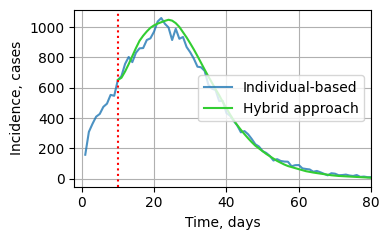

In [35]:
fig, ax = plt.subplots(1,1, figsize=(4,2.5))


ax.plot(seed_df.incidence, label='Individual-based',
        color='tab:blue',alpha=.8)

ax.plot(np.arange(seed_df.shape[0]-switch)+switch, 
        pd.Series(predicted_Inc), label='Hybrid approach',
        color='limegreen',alpha=1)
#ax[0].plot(np.arange(switch, 60), predicted_Inc, ls='--', color='gray', label='Inc SEIR (from pred)')

ax.grid()
ax.axvline(switch, color='red', ls=':')
ax.legend()
    #ax.set_zorder(100)
    
plt.xlim(-2,80)
plt.legend(loc='right')
plt.ylabel('Incidence, cases')
plt.xlabel('Time, days')
plt.tight_layout()

plt.savefig('hybrid.png', dpi=150)

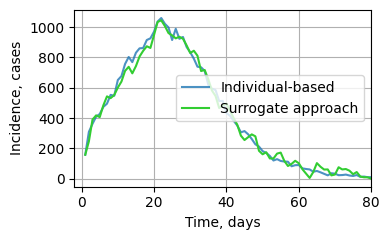

In [34]:
fig, ax = plt.subplots(1,1, figsize=(4,2.5))

np.random.seed(42)
noise = np.random.normal(0, 50, seed_df.shape[0]) 
ax.plot(seed_df.incidence.iloc[1:], label='Individual-based',
        color='tab:blue',alpha=.8)

fin = seed_df.incidence+noise
fin[fin<0] = 0
fin = fin.rolling(2).mean().fillna(method='bfill')
fin[1] = seed_df.incidence[1]
ax.plot(fin.iloc[1:], label='Surrogate approach',
        color='limegreen',alpha=1)
#ax[0].plot(np.arange(switch, 60), predicted_Inc, ls='--', color='gray', label='Inc SEIR (from pred)')

ax.grid()
ax.legend()
    #ax.set_zorder(100)
    
plt.xlim(-2,80)
plt.legend(loc='right')
plt.ylabel('Incidence, cases')
plt.xlabel('Time, days')
plt.tight_layout()

plt.savefig('surrogate.png', dpi=150)

## !

In [37]:
def apply_methods(seed_dirs='initial_data/initial_data_ba_10000/',
                  seed_numbers=[], on_incidence=False, 
                  switch_on_incidence=False,
                 idx_s=0, idx_e=11, show_fig_flag=False,
                 is_filename=False, sigma=0.1, gamma=0.08, perc_switch=0.01,
                  stoch=0,
                 suff_m='sw100k', suff='sw100k'):
    
    #df_seeds = pd.read_csv(df_seeds)
    if is_filename:
        col = 'file'
    else:
        col='seed_number'
        
    #seed_numbers = df_seeds[df_seeds.set=='test'][col].values[:n_seeds]

    types_start_day = ['fraq_people']#, 'roll_var', 'roll_var_seq']

    methods = ['last value','expanding mean last value',
               'median beta', 
               #'regression (day)',
               'regression beta', #'arimax',
               'lstm'
              ]

    new_labels = ['last_value', 'expanding_mean_last_value', 

            'median_beta', #'regression_day',
            'regression_beta', #'arimax',
                  'lstm_day_E_previous_I'
                 ]

    for type_start_day in types_start_day:

        for beta_pred,new_label in zip(methods[idx_s:idx_e], 
                                       new_labels[idx_s:idx_e]):

            if 'median' in beta_pred:
                model_path = f'{suff_m}_median_beta.csv'
            elif 'regression beta' in  beta_pred:
                model_path = f'{suff_m}_regression_bt.joblib'
            elif 'lstm' in beta_pred:
                model_path = f'{suff_m}_lstm_4_001_s10'   
            else:
                model_path=''
            print('path: ', model_path)
            if stoch > 0:
                stochastic = True
            try:
                all_rmse_I, all_rmse_Inc, all_rmse_Beta, \
                all_r2, all_r2_Inc, all_r2_full, all_r2_Inc_full,\
                all_peak, \
                    execution_time, start_days = plot_hyb.main_f(I_prediction_method='seir', 
                                        count_stoch_line=stoch, 
                                        beta_prediction_method=beta_pred, 
                                        type_start_day=type_start_day, 
                                        seed_numbers=seed_numbers, 
                                        show_fig_flag=show_fig_flag,
                                        seed_dirs=seed_dirs, 
                                        sigma=sigma, gamma=gamma, 
                                        ax=None, model_path=model_path,
                                        perc_switch=perc_switch,
                                        is_filename=is_filename,
                                        on_incidence=on_incidence,
                                        switch_on_incidence=switch_on_incidence)
                
                # creating a dataframe for peaks
                all_peak = pd.DataFrame(all_peak, 
                                columns=['actual_peak_I', 'predicted_peak_I', 
                                        'actual_peak_Inc', 'predicted_peak_inc',
                                        'actual_peak_day', 'predicted_peak_day',
                                        'actual_peak_day_Inc', 'predicted_peak_day_inc'])
                # creating a dataframe for peaks RMSE, predicted time, start day
                rmse_df = pd.DataFrame({
                    'rmse_I': all_rmse_I,
                    'rmse_Inc': all_rmse_Inc,
                    'rmse_Beta': all_rmse_Beta,
                    'r2': all_r2,
                    'r2_Inc': all_r2_Inc,
                    'r2_full': all_r2_full,
                    'r2_Inc_full': all_r2_Inc_full,
                    'time_predict': execution_time,
                    f'{type_start_day}': start_days})

                # merging dataframes
                results = pd.concat([rmse_df, all_peak], axis=1)
                folder_name = seed_dirs.split('/')[-2]
                
            except FileNotFoundError:
                pass
                
            if not show_fig_flag:
                path = f'results/{folder_name}/{type_start_day}/'
                if not os.path.exists(path):
                    os.makedirs(path)
                results.to_csv(f'{path}/{new_label}_results_{suff}.csv', 
                           index=False)
                

In [3]:
sw = pd.read_csv('train_files.csv').values
sw1 = pd.read_csv('test_files.csv').values
sw2 = pd.read_csv('val_files.csv').values

In [4]:
sw.shape, sw1.shape, sw2.shape

((36000, 1), (24000, 1), (12000, 1))

In [38]:
seed_dirs="../long_sw_100000_fin/"
sw = pd.read_csv('test_files.csv').values

In [17]:
float(beta)

0.1

In [19]:
_, beta, gc,dc, initi, alpha, _, seed = sw[100][0].split('_')

f'p_{round(float(beta), 2)}_{gc}_{dc}_{initi}_{round(float(alpha), 2)}_seed_{seed}'

'p_0.1_0.3_0.2_0.0001_0.51_seed_0.csv'

In [7]:
seed_dirs+sw[100][0]

'../long_sw_100000_fin/p_0.1_0.3_0.2_0.0001_0.5100000000000002_seed_0.csv'

In [22]:
_, beta, gc,dc, initi, alpha, _, seed = sw[100][0].split('_')
filen = f'p_{round(float(beta), 2)}_{gc}_{dc}_{initi}_{round(float(alpha), 2)}_seed_{seed}'

pd.read_csv(seed_dirs+filen)

,S,E,I,R,Beta
0,50991,0,10,48999,-0.0
1,50991,0,8,49001,-0.0
2,50991,0,6,49003,-0.0
3,50991,0,1,49008,-0.0
4,50991,0,1,49008,-0.0
...,...,...,...,...,...
145,50991,0,0,49009,0.0
146,50991,0,0,49009,0.0
147,50991,0,0,49009,0.0
148,50991,0,0,49009,0.0


In [44]:
sw[np.mod(np.arange(sw.size),10)!=0].reshape(-1,9)[-1]

array(['p_0.9899999999999995_0.3_0.2_0.0001_0.9500000000000006_seed_1.csv',
       'p_0.9899999999999995_0.3_0.2_0.0001_0.9500000000000006_seed_2.csv',
       'p_0.9899999999999995_0.3_0.2_0.0001_0.9500000000000006_seed_3.csv',
       'p_0.9899999999999995_0.3_0.2_0.0001_0.9500000000000006_seed_4.csv',
       'p_0.9899999999999995_0.3_0.2_0.0001_0.9500000000000006_seed_5.csv',
       'p_0.9899999999999995_0.3_0.2_0.0001_0.9500000000000006_seed_6.csv',
       'p_0.9899999999999995_0.3_0.2_0.0001_0.9500000000000006_seed_7.csv',
       'p_0.9899999999999995_0.3_0.2_0.0001_0.9500000000000006_seed_8.csv',
       'p_0.9899999999999995_0.3_0.2_0.0001_0.9500000000000006_seed_9.csv'],
      dtype=object)

In [45]:
sw[::10][-1]

array(['p_0.9899999999999995_0.3_0.2_0.0001_0.9500000000000006_seed_0.csv'],
      dtype=object)

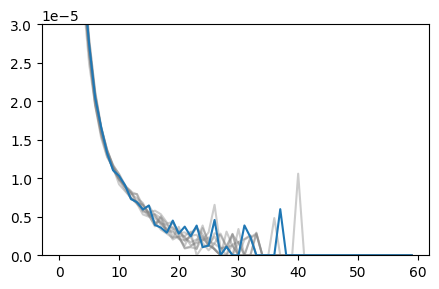

In [56]:
all_df2 = []
plt.subplots(figsize=(5,3))
for i in sw[np.mod(np.arange(sw.size),10)!=0].reshape(-1,9)[-1].ravel():
    d = pd.read_csv(seed_dirs+i).iloc[:60,:]
    all_df2.append(d)
    plt.plot(d.Beta, color='gray', alpha=.4)
plt.ylim(0,3e-5)

d = pd.read_csv(seed_dirs+sw[::10][-1][0]).iloc[:60,:]
all_df2.append(d)
plt.plot(d.Beta)

In [58]:
def decay(t, b0, q, phi):
    #return [b0*np.exp(-q*tt) for tt in t]
    return [b0*((1-phi)*np.exp(-q*tt)+phi) for tt in t]


def combinedFunction(tdata, b0, q, phi):
    # single data reference passed in, extract separate data
    res = []
    
    for i in range(9):
        #print(b0[i])
        result = decay(tdata, b0[i], q, phi)
        res.append(result)
    return np.array(res).ravel()

def get_i_inc(switch, predicted_beta, gamma, delta):
    y = seed_df.iloc[switch,:4]
    S,E,I,R = seir_discrete.seir_model(y, np.arange(switch, 60), 
                            np.array(predicted_beta), gamma, delta, 
                            'det', True).T

    predicted_Inc = np.zeros((1, 60-switch))

    from_last = seed_df['incidence'].iloc[switch]
    predicted_Inc[0] = np.append(from_last, 
                               (E[:-1] - E[1:]) - \
                                   (S[1:] - S[:-1]))
    predicted_Inc[0][predicted_Inc[0]<0] = 0
    
    return I, predicted_Inc[0]

In [48]:
all_df2[-1]

,S,E,I,R,Beta
0,94991,0,10,4999,0.003966
1,91224,3202,530,5044,0.000103
2,86256,6719,1741,5284,0.000062
3,77007,13116,4018,5859,0.000047
4,62487,22419,8096,6998,0.000036
...,...,...,...,...,...
145,317,0,0,99683,0.000000
146,317,0,0,99683,0.000000
147,317,0,0,99683,0.000000
148,317,0,0,99683,0.000000


In [41]:
seed_df[seed_df.I > 0.01*N]

,S,E,I,R,Beta,incidence


In [62]:
from scipy.optimize import curve_fit
import seir_discrete


coeffs for q and phi:  [0.25943804 0.0144178 ]
switch on day  2


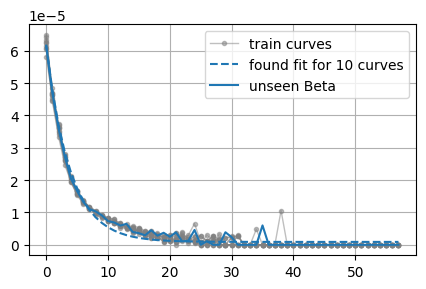

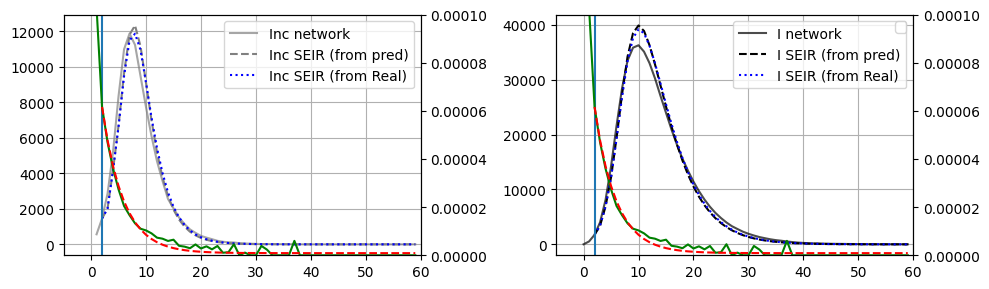

In [67]:
# exp. decay is good, but how to estimate q? (and phi?)
N = 1e5

seed_df = all_df2[-1]
chosen_col='incidence'
temp = seed_df[['E','S']].shift([0,1])
# Inc_t = (E_t-1 - E_t) - (S_t - S_t-1)
seed_df['incidence'] = (temp['E_1'] - temp['E_0']) - \
                    (temp['S_0'] - temp['S_1'])
            
switch = seed_df[seed_df.I > 0.01*N].index[0]
gamma = .3
delta = .2
b0 = seed_df.Beta.iloc[switch]

n = 9
#predicted_beta = [seed_df.iloc[switch]['Beta'] for i in np.arange(switch, 60)]
tdata = np.concatenate([np.arange(switch,60)-switch for i in range(n)])
comboData = np.array([all_df2[i].Beta.iloc[switch:].values for i in range(n)])
# curve fit the combined data to the combined function
coeffs, _ = curve_fit(lambda t, q, phi:combinedFunction(np.arange(switch,60)-switch, 
                                                        comboData[:,0], 
                                                        q, phi), 
                      tdata, comboData.ravel())
print('coeffs for q and phi: ',coeffs)

fig, ax = plt.subplots(1,1, figsize=(5,3))
ax.plot(comboData.T, lw=1, marker='.', color='gray', 
        alpha=.5, label =['train curves']+[None] * (8))
ax.plot(decay(tdata[:60-switch], all_df2[-1].Beta[switch], *coeffs), 
         ls='--', label='found fit for 10 curves')
ax.plot(all_df2[-1].Beta[switch:].values, color='tab:blue', 
        label='unseen Beta')
ax.grid()
ax.legend()


#phi = seed_df.iloc[switch]['Beta'] / delta#delta / seed_df.iloc[switch]['Beta']
predicted_beta = decay( np.arange(switch,60)-switch, b0, *coeffs)


I, predicted_Inc = get_i_inc(switch, predicted_beta, gamma, delta)

real_beta = seed_df.iloc[switch:]['Beta']
Ir, predicted_Incr = get_i_inc(switch, real_beta, gamma, delta)

print('switch on day ', switch)

#________________________________________________________

fig, ax = plt.subplots(1,2, figsize=(10,3))
ax = ax.flatten()

ax[0].plot(seed_df.incidence, label='Inc network',color='gray',alpha=.7)
ax[0].plot(np.arange(switch, 60), predicted_Inc, 
           ls='--', color='gray', label='Inc SEIR (from pred)')
ax[0].plot(np.arange(switch, 60), predicted_Incr, 
           ls=':', color='blue', label='Inc SEIR (from Real)')

ax[1].plot(seed_df.I, label='I network',color='black',alpha=.7)
ax[1].plot(np.arange(switch, 60), I, 
           ls='--', color='black', label='I SEIR (from pred)')
ax[1].plot(np.arange(switch, 60), Ir, 
           ls=':', color='blue', label='I SEIR (from Real)')

for ax in [ax[0], ax[1]]:
    axb = ax.twinx()
    axb.plot(seed_df.Beta, color='green')
    plt.xlim(-5,60)
    ax.grid()
    ax.axvline(switch)
    axb.plot(np.arange(switch, 60), np.array(predicted_beta), 
             ls='--', color='red')
    axb.set_ylim(0, 1e-4)
    ax.legend()
    #ax.set_zorder(100)
    
#axb.set_ylim(0, 1e-6)
plt.legend()
plt.tight_layout()

coeffs for q and phi:  [0.21893332 0.0173473 ]
switch on day  4


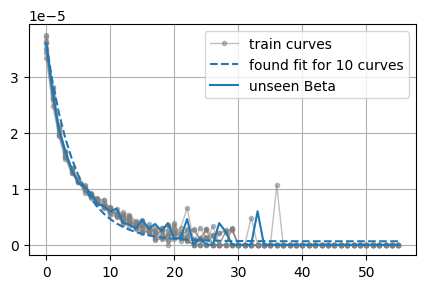

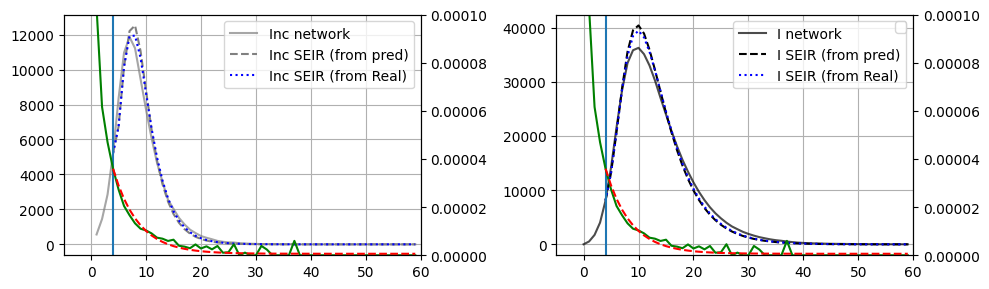

In [69]:
# exp. decay is good, but how to estimate q? (and phi?)
N = 1e5

seed_df = all_df2[-1]
chosen_col='incidence'
temp = seed_df[['E','S']].shift([0,1])
# Inc_t = (E_t-1 - E_t) - (S_t - S_t-1)
seed_df['incidence'] = (temp['E_1'] - temp['E_0']) - \
                    (temp['S_0'] - temp['S_1'])
            
switch = seed_df[seed_df.I > 0.05*N].index[0]
gamma = .3
delta = .2
b0 = seed_df.Beta.iloc[switch]

n = 9
#predicted_beta = [seed_df.iloc[switch]['Beta'] for i in np.arange(switch, 60)]
tdata = np.concatenate([np.arange(switch,60)-switch for i in range(n)])
comboData = np.array([all_df2[i].Beta.iloc[switch:].values for i in range(n)])
# curve fit the combined data to the combined function
coeffs, _ = curve_fit(lambda t, q, phi:combinedFunction(np.arange(switch,60)-switch, 
                                                        comboData[:,0], 
                                                        q, phi), 
                      tdata, comboData.ravel())
print('coeffs for q and phi: ',coeffs)

fig, ax = plt.subplots(1,1, figsize=(5,3))
ax.plot(comboData.T, lw=1, marker='.', color='gray', 
        alpha=.5, label =['train curves']+[None] * (8))
ax.plot(decay(tdata[:60-switch], all_df2[-1].Beta[switch], *coeffs), 
         ls='--', label='found fit for 10 curves')
ax.plot(all_df2[-1].Beta[switch:].values, color='tab:blue', 
        label='unseen Beta')
ax.grid()
ax.legend()


#phi = seed_df.iloc[switch]['Beta'] / delta#delta / seed_df.iloc[switch]['Beta']
predicted_beta = decay( np.arange(switch,60)-switch, b0, *coeffs)


I, predicted_Inc = get_i_inc(switch, predicted_beta, gamma, delta)

real_beta = seed_df.iloc[switch:]['Beta']
Ir, predicted_Incr = get_i_inc(switch, real_beta, gamma, delta)

print('switch on day ', switch)

#________________________________________________________

fig, ax = plt.subplots(1,2, figsize=(10,3))
ax = ax.flatten()

ax[0].plot(seed_df.incidence, label='Inc network',color='gray',alpha=.7)
ax[0].plot(np.arange(switch, 60), predicted_Inc, 
           ls='--', color='gray', label='Inc SEIR (from pred)')
ax[0].plot(np.arange(switch, 60), predicted_Incr, 
           ls=':', color='blue', label='Inc SEIR (from Real)')

ax[1].plot(seed_df.I, label='I network',color='black',alpha=.7)
ax[1].plot(np.arange(switch, 60), I, 
           ls='--', color='black', label='I SEIR (from pred)')
ax[1].plot(np.arange(switch, 60), Ir, 
           ls=':', color='blue', label='I SEIR (from Real)')

for ax in [ax[0], ax[1]]:
    axb = ax.twinx()
    axb.plot(seed_df.Beta, color='green')
    plt.xlim(-5,60)
    ax.grid()
    ax.axvline(switch)
    axb.plot(np.arange(switch, 60), np.array(predicted_beta), 
             ls='--', color='red')
    axb.set_ylim(0, 1e-4)
    ax.legend()
    #ax.set_zorder(100)
    
#axb.set_ylim(0, 1e-6)
plt.legend()
plt.tight_layout()

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta
path:  sw100k_lstm_4_001_s10
lstm


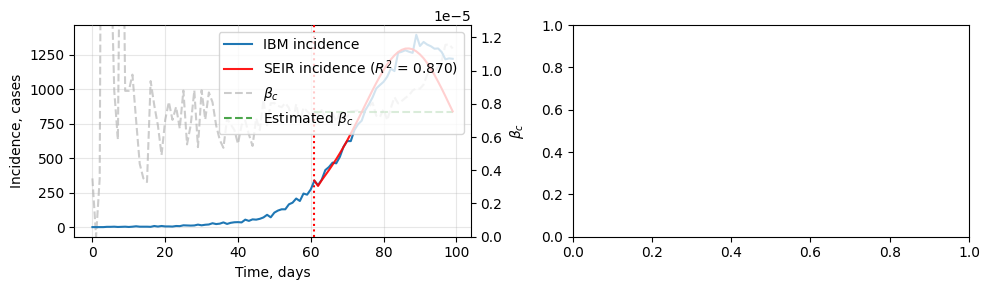

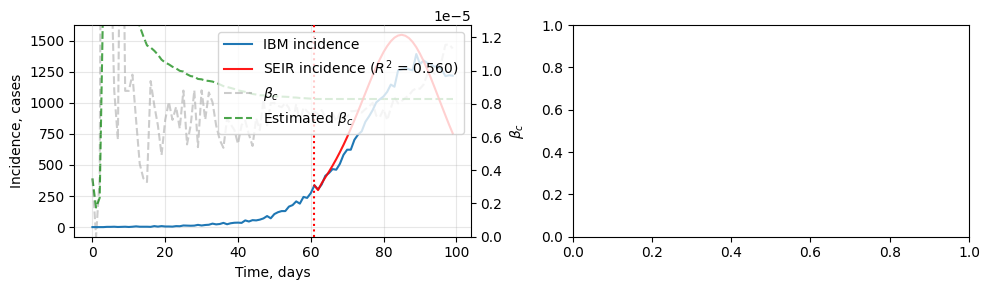

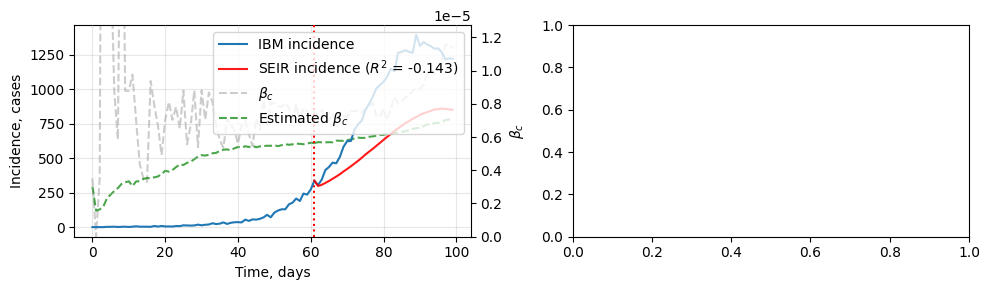

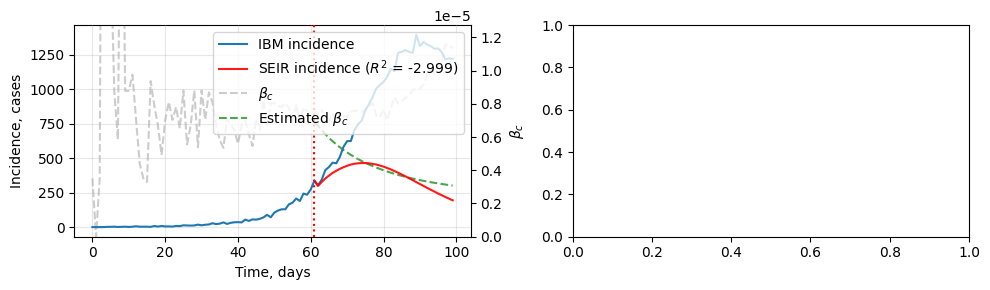

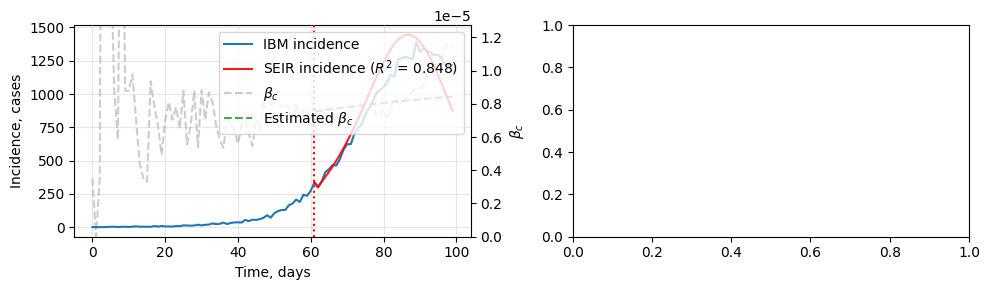

In [29]:
apply_methods(seed_dirs="../long_sw_100000_fin/",
              seed_numbers=sw[-900:-899], on_incidence=True,
              switch_on_incidence=False,
              idx_s=0, idx_e=5, show_fig_flag=True,
              is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=.01,
              suff_m='sw100k', suff=f'hh')

In [ ]:
for p,l in zip([.03,.04,.05,.06,.07
               ], 
               ['3','4','5','6','7'
               ]):
    print()
    print(l)
    apply_methods(seed_dirs="../long_sw_100000_fin/",
              seed_numbers=sw[::10], on_incidence=True,
              switch_on_incidence=False,
              idx_s=0, idx_e=4, show_fig_flag=False,
              is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=p,
              suff_m='long_sw100k', suff=f'long_sw100k_sI_fullR_{l}')
    plt.close()


3
path:  
last value
path:  
expanding mean last value
path:  long_sw100k_median_beta.csv
median beta
path:  long_sw100k_regression_bt.joblib
regression beta

4
path:  
last value
path:  
expanding mean last value
path:  long_sw100k_median_beta.csv
median beta
path:  long_sw100k_regression_bt.joblib
regression beta


In [6]:
for p,l in zip([#0.01,
                #0.005,
                0.0075,
                0.0125,
                0.015
               ], 
               [#'1',
                #'05',
                   '075',
                '125',
                   '15'
               ]):
    print()
    print(l)
    apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              switch_on_incidence=False,
              idx_s=0, idx_e=6, show_fig_flag=False,
              is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=p,
              suff_m='sw100k', suff=f'sw100k_sI_fullR_{l}')
    plt.close()


075
path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta
path:  sw100k_lstm_4_001_s10
lstm

125
path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta
path:  sw100k_lstm_4_001_s10
lstm

15
path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta
path:  sw100k_lstm_4_001_s10
lstm


In [17]:
p, l = 0.01, 1
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10][102:104], on_incidence=True,
              switch_on_incidence=False,
              idx_s=2, idx_e=3, show_fig_flag=False,
              is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=p, stoch=0,
              suff_m='ba100k', suff=f'ba100k_sI_fullR_{l}')
plt.close()

path:  ba100k_median_beta.csv
median beta


In [7]:
%%time
# for lstm CPU times: total: 3h 41min 11s
# Wall time: 3h 1min 54s
#apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              switch_on_incidence=False,
              idx_s=4, idx_e=5, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01,
             suff_m='ba100k', suff='ba100k_sI')

path:  ba100k_lstm_4_001_s10
lstm
CPU times: total: 3h 41min 11s
Wall time: 3h 1min 54s


In [15]:
apply_methods(seed_dirs="../hybrid_surrogate/sim_data/new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              switch_on_incidence=False,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.005,
             suff_m='ba100k', suff=f'ba100k_sI_05')

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


In [16]:
apply_methods(seed_dirs="../hybrid_surrogate/sim_data/new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              switch_on_incidence=False,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.0075,
             suff_m='ba100k', suff=f'ba100k_sI_075')

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


In [17]:
apply_methods(seed_dirs="../hybrid_surrogate/sim_data/new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              switch_on_incidence=False,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.0125,
             suff_m='ba100k', suff=f'ba100k_sI_125')

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


In [18]:
apply_methods(seed_dirs="../hybrid_surrogate/sim_data/new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              switch_on_incidence=False,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.015,
             suff_m='ba100k', suff=f'ba100k_sI_15')

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


In [19]:
#for p,l in zip([0.005,0.0075,0.0125,0.015], 
               ['05','075','1','125','15']):
    apply_methods(seed_dirs="../hybrid_surrogate/sim_data/new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              switch_on_incidence=False,
              idx_s=4, idx_e=5, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=p,
             suff_m='ba100k_', suff=f'ba100k_sI_all_{l}')
    

path:  ba100k_lstm_4_001_s10
lstm
path:  ba100k_lstm_4_001_s10
lstm
path:  ba100k_lstm_4_001_s10
lstm
path:  ba100k_lstm_4_001_s10
lstm


path:  ba100k_regression_bt.joblib
regression beta
path:  ba100k_lstm_4_001_s10
lstm
CPU times: total: 31.2 ms
Wall time: 36 ms


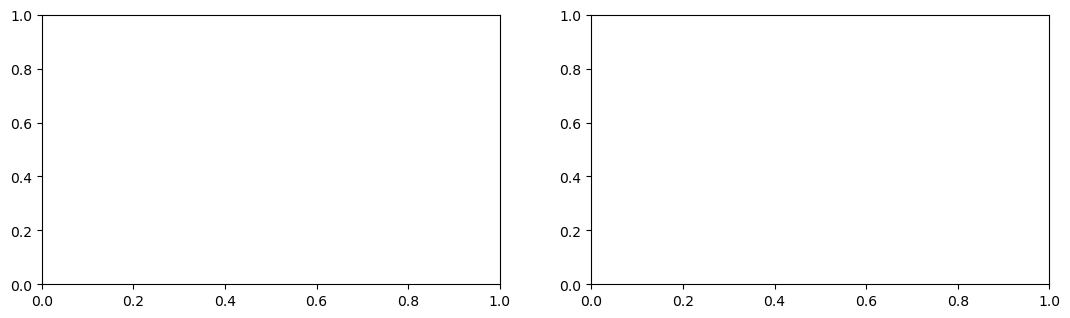

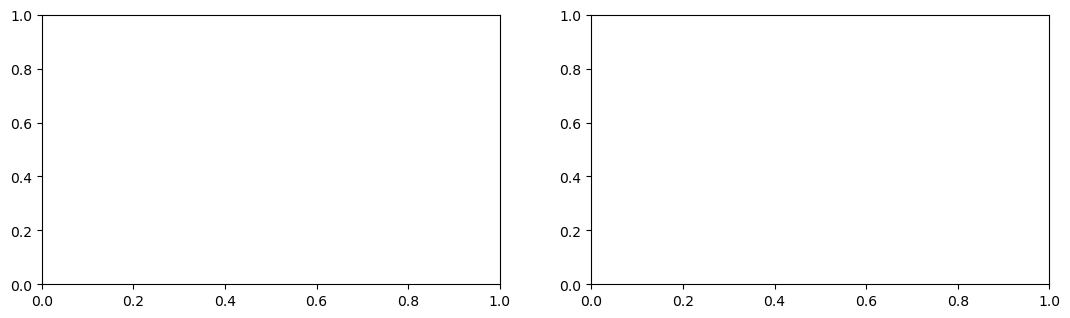

In [12]:
%%time
k = 2380
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[-2:], on_incidence=True,
              switch_on_incidence=False,
              idx_s=3, idx_e=5, show_fig_flag=True,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01,
             suff_m='ba100k', suff='ba100k_10')

In [18]:
sw[::10][140:]

array([['p_0.14999999999999997_0.3_0.2_0.0001_0.2800000000000001_seed_0.csv'],
       ['p_0.14999999999999997_0.3_0.2_0.0001_0.3000000000000001_seed_0.csv'],
       ['p_0.14999999999999997_0.3_0.2_0.0001_0.34000000000000014_seed_0.csv'],
       ...,
       ['p_0.9899999999999995_0.3_0.2_0.0001_0.9100000000000006_seed_0.csv'],
       ['p_0.9899999999999995_0.3_0.2_0.0001_0.9400000000000006_seed_0.csv'],
       ['p_0.9899999999999995_0.3_0.2_0.0001_0.9500000000000006_seed_0.csv']],
      shape=(2260, 1), dtype=object)

path:  ba100k_regression_bt.joblib
regression beta
path:  ba100k_lstm_4_001_s10
lstm
CPU times: total: 891 ms
Wall time: 1.02 s


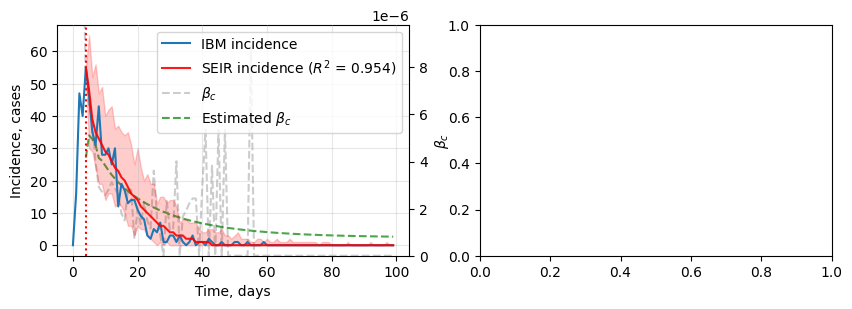

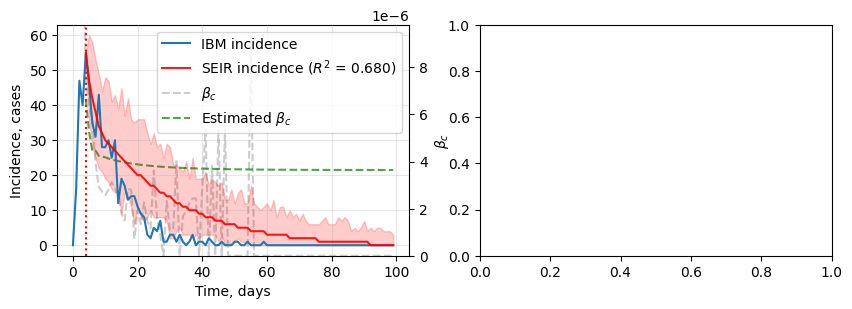

In [4]:
%%time
k = 145
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10][k:k+1], on_incidence=True,
              switch_on_incidence=False,
              idx_s=3, idx_e=5, show_fig_flag=True,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01, stoch=100,
             suff_m='ba100k', suff='ba100k_10')

path:  ba100k_lstm_4_001_s10
lstm
CPU times: total: 1.52 s
Wall time: 1.33 s


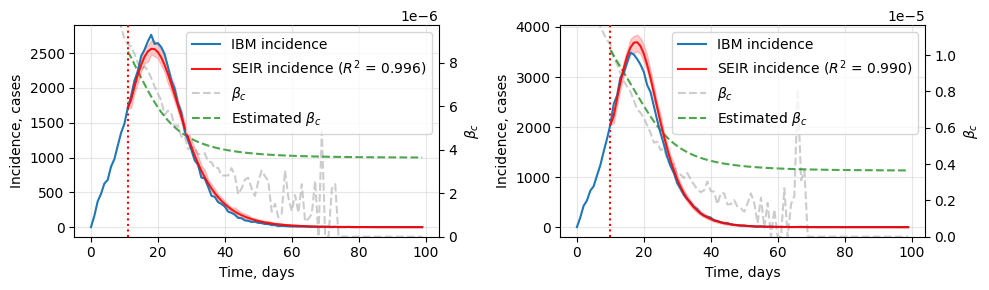

In [63]:
%%time
k = 1100
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10][k:k+2], on_incidence=True,
              switch_on_incidence=False,
              idx_s=4, idx_e=5, show_fig_flag=True,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.05, stoch=100,
             suff_m='ba100k', suff='ba100k_10')

plt.savefig('ii.png', bbox_inches='tight')

path:  ba100k_regression_bt.joblib
regression beta
path:  ba100k_lstm_4_001_s10
lstm
CPU times: total: 62.5 ms
Wall time: 49.4 ms


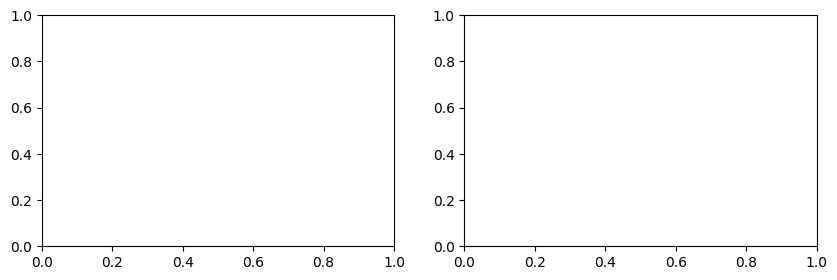

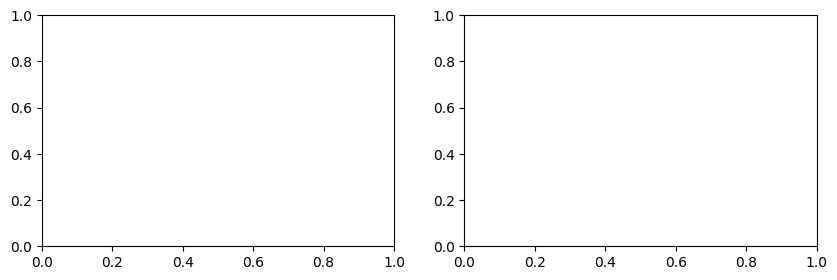

In [39]:
%%time
k = 2220
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10][k:k+1], on_incidence=True,
              switch_on_incidence=False,
              idx_s=3, idx_e=5, show_fig_flag=True,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01, stoch=100,
             suff_m='ba100k', suff='ba100k_10')

In [6]:
types_start_day = ['fraq_people']#, 'roll_var', 'roll_var_seq']

methods = ['last value','expanding mean last value',
               'median beta', 
               #'regression (day)',
               'regression beta', #'arimax',
               'lstm'
              ]

new_labels = ['last_value', 'expanding_mean_last_value', 

            'median_beta', #'regression_day',
            'regression_beta', #'arimax',
                  'lstm_day_E_previous_I'
                 ]
seed_dirs="../new_ba_100000/"

model_pathr = f'ba100k_regression_bt.joblib'
model_pathl = f'ba100k_lstm_4_001_s10'   

sigma=0.3
gamma=0.2
perc_switch=0.01
stoch=100

regression beta
lstm
regression beta
lstm


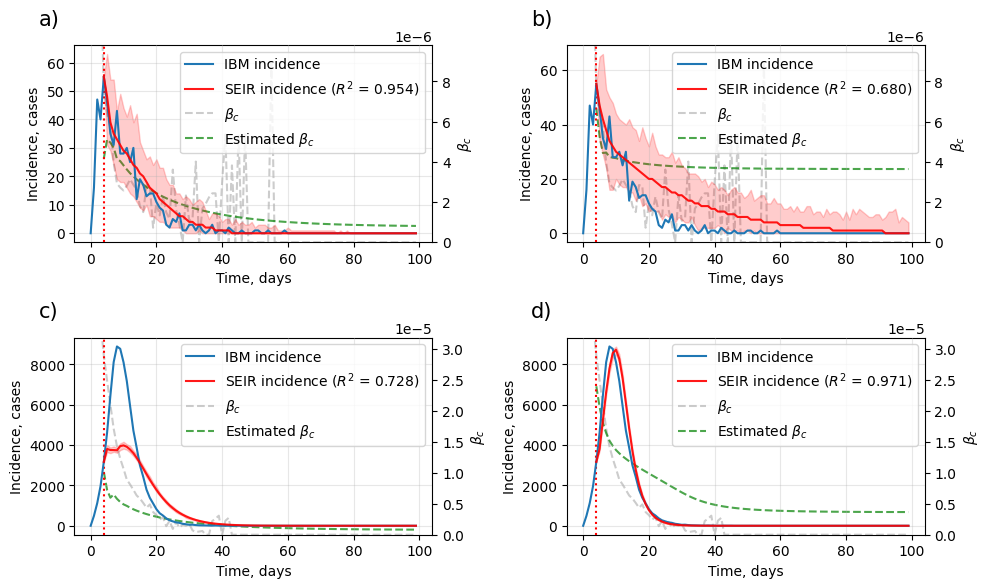

In [7]:
k = 145
fig, ax = plt.subplots(2,2, figsize=(10, 6))
ax = ax.flatten()

plot_hyb.main_f(I_prediction_method='seir', count_stoch_line=100, 
                beta_prediction_method=methods[-2], 
                type_start_day=types_start_day[0], 
                seed_numbers=sw[::10][k:k+1], show_fig_flag=True,
                seed_dirs=seed_dirs, sigma=sigma, gamma=gamma, 
                ax=[ax[0]], model_path=model_pathr,perc_switch=perc_switch,
                is_filename=True,on_incidence=True,switch_on_incidence=False)
ax[0].text(-0.1, 1.1, 'a)',
           transform=ax[0].transAxes, size=15)

plot_hyb.main_f(I_prediction_method='seir', count_stoch_line=100, 
                beta_prediction_method=methods[-1], 
                type_start_day=types_start_day[0], 
                seed_numbers=sw[::10][k:k+1], show_fig_flag=True,
                seed_dirs=seed_dirs, sigma=sigma, gamma=gamma, 
                ax=[ax[1]], model_path=model_pathl,perc_switch=perc_switch,
                is_filename=True,on_incidence=True,switch_on_incidence=False);
ax[1].text(-0.1, 1.1, 'b)',
           transform=ax[1].transAxes, size=15)
k = 2320
plot_hyb.main_f(I_prediction_method='seir', count_stoch_line=100, 
                beta_prediction_method=methods[-2], 
                type_start_day=types_start_day[0], 
                seed_numbers=sw[::10][k:k+1], show_fig_flag=True,
                seed_dirs=seed_dirs, sigma=sigma, gamma=gamma, 
                ax=[ax[2]], model_path=model_pathr,perc_switch=perc_switch,
                is_filename=True,on_incidence=True,switch_on_incidence=False)
ax[2].text(-0.1, 1.1, 'c)',
           transform=ax[2].transAxes, size=15)

plot_hyb.main_f(I_prediction_method='seir', count_stoch_line=100, 
                beta_prediction_method=methods[-1], 
                type_start_day=types_start_day[0], 
                seed_numbers=sw[::10][k:k+1], show_fig_flag=True,
                seed_dirs=seed_dirs, sigma=sigma, gamma=gamma, 
                ax=[ax[3]], model_path=model_pathl,perc_switch=perc_switch,
                is_filename=True,on_incidence=True,switch_on_incidence=False);
ax[3].text(-0.1, 1.1, 'd)',
           transform=ax[3].transAxes, size=15)

plt.tight_layout()
plt.savefig(f'results/regr_lstm.pdf', format='pdf', bbox_inches='tight')

In [139]:
ax.flatten()

array([<Axes: >, <Axes: >], dtype=object)

In [3]:
import joblib

In [64]:
k = 20380

seed_dirs="../hybrid_surrogate/sim_data/new_ba_100000/"
seed_df = pd.read_csv(seed_dirs+sw[k][0])
temp = seed_df[['E','S']].shift([0,1])
# Inc_t = (E_t-1 - E_t) - (S_t - S_t-1)
seed_df['incidence'] = (temp['E_1'] - temp['E_0']) - \
                    (temp['S_0'] - temp['S_1'])
seed_df = seed_df[(seed_df['E'] > 0)|(seed_df['I'] > 0)
                         ].fillna(0)
seed_df.replace([np.inf, -np.inf], 0, inplace=True)
    
scaler = joblib.load(f'ba100k_lstm_4_001_s10.pkl')
model = predict_Beta_I.load_model(f'ba100k_lstm_4_001_s10.keras')
window_size=4
predicted_days = [4,5]

In [65]:
seed_df[['Beta']].shift(np.arange(window_size)
                            ).iloc[4]

Beta_0    0.000012
Beta_1    0.000015
Beta_2    0.000023
Beta_3    0.000051
Name: 4, dtype: float64

In [66]:
inp = seed_df[['Beta']].shift(np.arange(window_size)
                            ).iloc[predicted_days[0]
                                  ].values
#[t, t-1, t-2, t-3]
inp = np.log(inp+1e-7)
#[t-3, ... t]
sc_inp = scaler.transform(inp[::-1].reshape(-1, 1))


In [67]:
sc_inp.shape

(4, 1)

In [68]:
np.array(sc_inp)

array([[1.79174136],
       [1.36085754],
       [1.1364212 ],
       [1.02015941]])

In [48]:
%%timeit
sc = sc_inp.reshape(1, 4, 1)
sc = tf.convert_to_tensor(sc)
model.predict(sc, verbose=0, batch_size=len(sc))

74.7 ms ± 4.67 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [50]:
%%timeit
sc = sc_inp.reshape(1, 4, 1)
sc = tf.convert_to_tensor(sc)
model(sc)

57.6 ms ± 5.8 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [56]:
%%timeit
sc = sc_inp.reshape(1, 4, 1)
sc = tf.convert_to_tensor(sc)
model.predict_on_batch(sc)

1.38 ms ± 23.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [52]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 4, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 4, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,972 (390.52 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 49,987 (195.27 KB)

In [91]:
%%timeit
sc = sc_inp.reshape(1, 4, 1)
for i in range(predicted_days[0], 
               30): 
    pred = model(sc)
    
    # add pred in the beginning: [y_hat, t, t-1, t-2]
    result = np.empty_like(sc)
    result[:,:1] = pred
    result[:,1:] = sc[:,:-1]
    
    sc = result

1.65 s ± 86.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [92]:
preds = []
sc = sc_inp.reshape(1, 4, 1)
for i in range(predicted_days[0], 
               30): 
    pred = model(sc)
    
    # add pred in the beginning: [y_hat, t, t-1, t-2]
    result = np.empty_like(sc)
    result[:,:1] = pred
    result[:,1:] = sc[:,:-1]
    preds.append(pred)
    sc = result

In [93]:
pred

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[-0.72532874]], dtype=float32)>

In [103]:
scaler.transform(np.array([np.log(1e-7)]).reshape(-1, 1))

array([[-1.61178852]])

In [107]:
tf.convert_to_tensor([[0]])

<tf.Tensor: shape=(1, 1), dtype=int32, numpy=array([[0]], dtype=int32)>

In [77]:
preds2 = []
sc = sc_inp.reshape(1, 4, 1)
for i in range(predicted_days[0], 
               30): 
    pred = model.predict(sc, verbose=0)
    
    # add pred in the beginning: [y_hat, t, t-1, t-2]
    result = np.empty_like(sc)
    result[:,:1] = pred
    result[:,1:] = sc[:,:-1]
    preds2.append(pred)
    sc = result

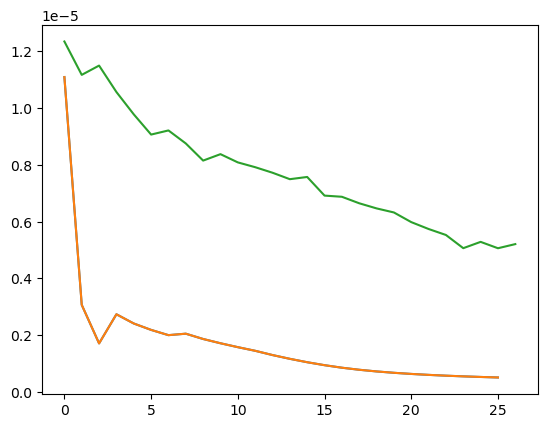

In [85]:
fastp = tf.convert_to_tensor(preds).numpy()
fastp = scaler.inverse_transform(fastp[::,0])
fastp = np.exp(fastp.flatten())
plt.plot(fastp)

sp = np.array(preds2)
sp = scaler.inverse_transform(sp[::,0])
sp = np.exp(sp.flatten())
plt.plot(sp)

k = seed_df.Beta.iloc[4:31].values
#k = np.log(k+1e-7)
#[t-3, ... t]
#k = scaler.transform(k[::-1].reshape(-1, 1))
plt.plot(k)

In [58]:
%%timeit
sc = sc_inp.reshape(1, 4, 1)
for i in range(predicted_days[0], 
               30): 
    pred = model.predict_on_batch(sc)
    
    # add pred in the beginning: [y_hat, t, t-1, t-2]
    result = np.empty_like(sc)
    result[:,:1] = pred
    result[:,1:] = sc[:,:-1]
    
    sc = result

37 ms ± 1.69 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [29]:
%%timeit
scaler.inverse_transform(tf.convert_to_tensor(predicted_beta)[::,0])

559 μs ± 48.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [32]:
%%timeit
scaler.inverse_transform(tf.convert_to_tensor(predicted_beta
                                             ).numpy()[::,0])

250 μs ± 30.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [39]:
tf.convert_to_tensor(predicted_beta
                                             ).numpy()[::,0]

array([[ 0.9323965 ],
       [ 0.04722741],
       [-0.08867677],
       [ 0.12089441],
       [ 0.04319718],
       [-0.04445764],
       [-0.07811101],
       [-0.09349389],
       [-0.16199204],
       [-0.22276512],
       [-0.27792698],
       [-0.3347783 ],
       [-0.39495432],
       [-0.4483158 ],
       [-0.49557042],
       [-0.53780425],
       [-0.5754832 ],
       [-0.60836583],
       [-0.63741356],
       [-0.6633911 ],
       [-0.68676823],
       [-0.7078801 ],
       [-0.7271348 ],
       [-0.7448487 ],
       [-0.7612514 ],
       [-0.776533  ]], dtype=float32)

In [41]:
r = scaler.inverse_transform(tf.convert_to_tensor(predicted_beta
                                             ).numpy()[::,0])
np.exp(r.flatten())

array([1.06019515e-05, 2.09274708e-06, 1.63126822e-06, 2.39531073e-06,
       2.07734251e-06, 1.76899971e-06, 1.66317091e-06, 1.61692742e-06,
       1.42613351e-06, 1.27579221e-06, 1.15309786e-06, 1.03898174e-06,
       9.30470833e-07, 8.43766713e-07, 7.73755403e-07, 7.16113959e-07,
       6.68322912e-07, 6.29229703e-07, 5.96601751e-07, 5.68858638e-07,
       5.44997135e-07, 5.24309087e-07, 5.06126582e-07, 4.89956278e-07,
       4.75443755e-07, 4.62310766e-07], dtype=float32)

In [69]:
tf.__version__

'2.18.1'

In [52]:
model(sc)

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.7728366]], dtype=float32)>

In [39]:
model.predict(sc, verbose=0)

array([[0.77283657]], dtype=float32)

In [23]:
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, perc_switch=0.005,
             suff_m='ba100k', suff='_inc_05')

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


In [29]:
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, perc_switch=0.0075,
             suff_m='ba100k', suff='_inc_075')

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


In [10]:
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01,
             suff_m='ba100k', suff='_inc_01')

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


In [25]:
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, perc_switch=0.0125,
             suff_m='ba100k', suff='_inc_0125')

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


In [26]:
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, perc_switch=0.015,
             suff_m='ba100k', suff='_inc_015')

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


## sw

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta
path:  sw100k_lstm_4_001_s10
lstm


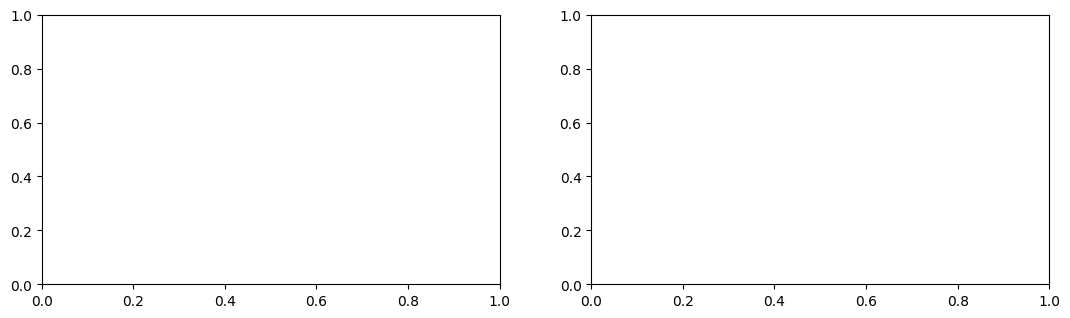

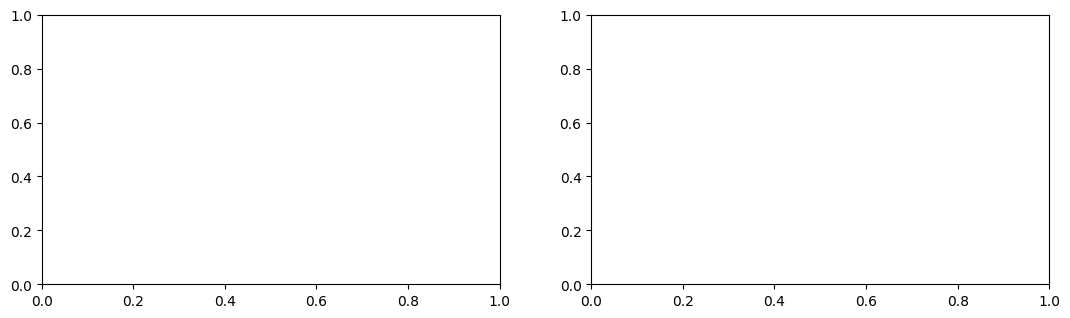

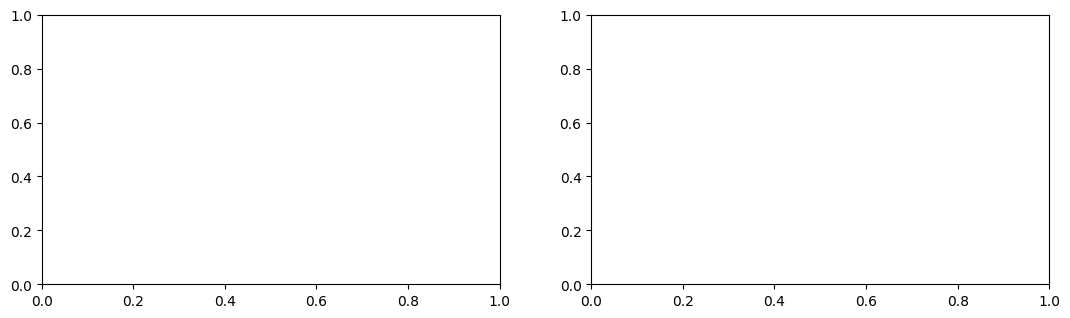

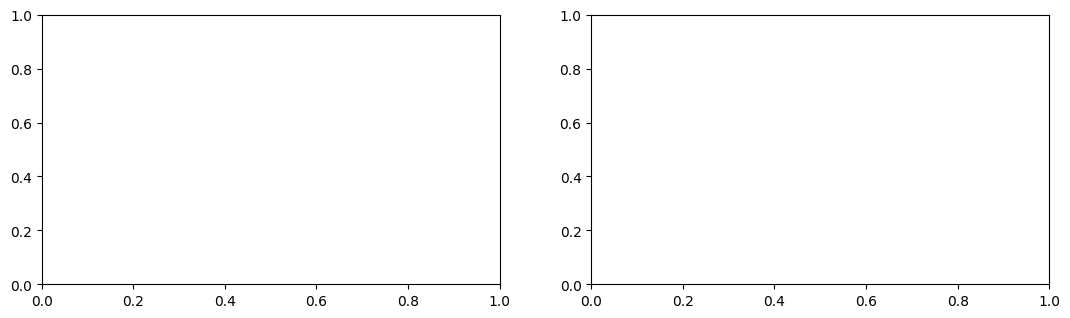

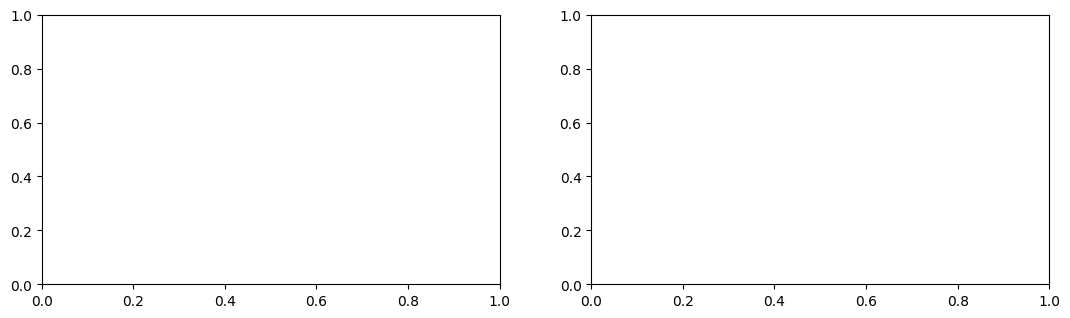

In [22]:
sw = pd.read_csv('test_files.csv').values
k = 22000
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[k:k+1], on_incidence=True,
              idx_s=0, idx_e=5, show_fig_flag=True,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01,
             suff_m='sw100k')


In [4]:
sw = pd.read_csv('test_files.csv').values
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.0005,
             suff_m='sw100k', suff='_inc_05')

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta


In [5]:
sw = pd.read_csv('test_files.csv').values
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.00075,
             suff_m='sw100k', suff='_inc_075')

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta


In [6]:
sw = pd.read_csv('test_files.csv').values
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01,
             suff_m='sw100k', suff='_inc_1')

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta


In [7]:
sw = pd.read_csv('test_files.csv').values
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.0125,
             suff_m='sw100k', suff='_inc_125')

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta


In [8]:
sw = pd.read_csv('test_files.csv').values
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.015,
             suff_m='sw100k', suff='_inc_15')

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta
